# Práctica P3: La Decisión Óptima de Consumo-Ahorro
**Proyecto MACRO-AI-COMP (Convocatoria INNOVA26, UMA / Banco Santander)**
*   **Código de Práctica**: LAB-P3-v1.0
*   **Capítulo de Referencia**: Capítulo 4, *An Introduction to Computational Macroeconomics* (Bongers, Gómez y Torres, Vernon Press, 2019)
*   **Autores**: Equipo Docente MACRO-AI-COMP
*   **Objetivo**: Analizar la decisión óptima intertemporal de un hogar en un ciclo de vida finito. Comprender cómo la tasa de interés real, la impaciencia subjetiva y la estructura temporal de ingresos determinan el perfil óptimo de consumo y la trayectoria de acumulación de activos financieros (ahorro/deuda).

---

## Objetivos de Aprendizaje
Al finalizar esta práctica, serás capaz de:
1.  **Comprender** el carácter intertemporal de la elección del consumidor y cómo el ahorro permite disociar el perfil de consumo del de ingresos.
2.  **Modelar** el problema de optimización dinámica del consumidor en tiempo discreto sujeto a restricciones presupuestarias secuenciales.
3.  **Analizar e Interpretar** la Ecuación de Euler y la condición de estado estacionario ($\bar{R} = \theta$).
4.  **Resolver** sistemas de ecuaciones no lineales (FOC) usando `fsolve` y problemas de optimización convexa directamente en Python usando `cvxpy`.
5.  **Evaluar** los efectos de shocks sobre los flujos de ingresos (salarios crecientes, jubilación) y de cambios en los parámetros del modelo ($\beta, R$) sobre los patrones de ahorro y deuda.


> **👋 BIENVENIDA A LA PRÁCTICA - LEER ANTES DE EMPEZAR**
> 
> *   **¿Nunca has usado Jupyter?** No te preocupes. Este cuaderno es interactivo. Haz clic en cualquier celda de código y pulsa **`Shift + Enter`** para ejecutarla. Ve de arriba a abajo en orden.
> *   **¿Se ha congelado o sale un asterisco `[*]` eterno?** Ve al menú superior y dale a `Kernel` ➔ `Restart`.
> *   **El objetivo** de esta práctica es que juegues con la economía. Cambia los números del código que representan impuestos, dinero o tecnología, vuelve a ejecutar y mira los gráficos. ¡No puedes romper nada!
>

### 🕹️ GUÍA RÁPIDA PARA DUMMIES - Consumo y Ahorro
*   **¿Qué estamos haciendo aquí?** Decidiendo cómo un consumidor debe repartir su dinero entre consumir hoy y ahorrar para mañana a lo largo de su vida.
*   **El dilema:** Si consumes todo hoy, pasas hambre mañana. Si ahorras todo, pasas hambre hoy. El modelo calcula el equilibrio óptimo (suavización del consumo).
*   **¡Prueba esto!** Cambia la tasa de interés o la paciencia del consumidor (factor de descuento) y observa cómo cambia la curva de consumo a lo largo del tiempo.


In [1]:
%%capture
# Esta celda se ejecuta silenciosamente. Si estás en Google Colab, instalará las librerías necesarias.
# En tu entorno local de desarrollo (venv), estas dependencias ya deberían estar instaladas.
import sys
if 'google.colab' in sys.modules:
    !pip install numpy scipy matplotlib ipywidgets cvxpy


In [2]:
# ==============================================================================
# IMPORTACIÓN DE MÓDULOS Y CONFIGURACIÓN DE RUTAS
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, Dropdown

# Añadir el directorio src al PATH de Python para poder importar el módulo macroaicomp
import sys
sys.path.append('../../src')

# Importar funciones del modelo modularizado (Core de la biblioteca)
from macroaicomp.models.consumption_savings import (
    ConsumptionSavingParameters,
    generate_income_profile,
    solve_foc_fsolve,
    solve_direct_cvxpy
)


## 1. El Marco Teórico: Optimización Intertemporal del Consumidor

El consumidor decide su nivel de consumo a lo largo de un ciclo de vida finito de $T$ periodos ($t = 0, 1, \dots, T-1$). Su objetivo es maximizar la suma descontada de utilidades subjetivas:

$$\max_{\{C_t\}_{t=0}^{T-1}} \sum_{t=0}^{T-1} \beta^t U(C_t)$$

Donde:
*   $C_t$ es el consumo en el periodo $t$.
*   $U(C_t)$ es la utilidad instantánea. Asumimos una **utilidad logarítmica** $U(C_t) = \ln(C_t)$, que cumple con ser estrictamente cóncava ($U_C > 0, U_{CC} < 0$, indicando utilidad marginal decreciente).
*   $\beta = \frac{1}{1+\theta}$ es el **factor de descuento intertemporal**, con $\theta > 0$ representando la tasa de preferencia temporal subjetiva (impaciencia).

### 1.1 Restricciones Presupuestarias y Condiciones de Contorno
La maximización está sujeta a la restricción presupuestaria en cada periodo:

$$C_t + B_t = (1 + R_{t-1})B_{t-1} + W_t$$

Donde:
*   $B_t$ es el stock de activos financieros al final del periodo $t$ (si es positivo, es acreedor/ahorro; si es negativo, es deudor/deuda).
*   $R_{t-1}$ es la tasa de interés real de los activos en el periodo anterior.
*   $W_t$ es el ingreso salarial exógeno en el periodo $t$.

Además, asumimos las siguientes condiciones de contorno:
1.  **Sin activos iniciales**: $B_{-1} = 0$, lo que implica que en el periodo $t=0$, $B_0 = W_0 - C_0$.
2.  **Condición Terminal**: $B_{T-1} = 0$, es decir, el consumidor no deja deudas ni herencias al final de su vida ($t = T-1$).

### 1.2 La Ecuación de Euler
Resolviendo el problema mediante el método de Lagrange, se obtiene la **Ecuación de Euler**, que gobierna la trayectoria óptima del consumo:

$$U_C(C_t) = \beta (1 + R_t) U_C(C_{t+1})$$

Para la utilidad logarítmica, la utilidad marginal es $U_C(C) = 1/C$, lo que reduce la ecuación de Euler a:

$$C_{t+1} = \beta (1 + R_t) C_{t}$$

Esta relación revela que:
*   Si $\beta (1+R) > 1$ (el interés real supera la impaciencia $\theta$), el consumo tiene **pendiente positiva** (crece con el tiempo).
*   Si $\beta (1+R) < 1$ (la impaciencia supera el interés real), el consumo tiene **pendiente negativa** (decrece).
*   Si $\beta (1+R) = 1$ (estado estacionario, $R = \theta$), el consumo es constante en todos los periodos.


In [3]:
# ==============================================================================
# CALIBRACIÓN DE REFERENCIA (Capítulo 4 - Libro original)
# ==============================================================================

params = ConsumptionSavingParameters()

print("CALIBRACIÓN ECONÓMICA BASE:")
print("-" * 50)
print(f"  Duración del ciclo de vida (T)  : {params.T} periodos")
print(f"  Factor de descuento (beta)      : {params.beta} (equivale a theta ≈ {((1-params.beta)/params.beta)*100:.2f}%)")
print(f"  Tasa de interés real (R)        : {params.R*100:.2f}%")
print("-" * 50)


CALIBRACIÓN ECONÓMICA BASE:
--------------------------------------------------
  Duración del ciclo de vida (T)  : 30 periodos
  Factor de descuento (beta)      : 0.97 (equivale a theta ≈ 3.09%)
  Tasa de interés real (R)        : 2.00%
--------------------------------------------------


## 2. Métodos de Resolución Computacional: FOC vs Optimización Directa

En macroeconomía aplicada, podemos resolver este tipo de modelos de dos formas:
1.  **Resolución de FOC (`fsolve`)**: Planteando las $T$ ecuaciones no lineales de Euler y la condición terminal $B_{T-1}=0$ para hallar el vector de consumo $C$.
2.  **Optimización Convexa Directa (`cvxpy`)**: Maximizar directamente la función objetivo bajo restricciones analíticas lineales.

A continuación, ejecutaremos ambos métodos con la calibración base y un salario constante $W=10$ para comprobar su equivalencia numérica.

*Nota sobre la errata de MATLAB:* La formulación en `fsolve` incluye la corrección terminal del salario ($W_T$) para forzar a que el saldo final $B_T$ sea exactamente $0.0$, emulando el Solver de Excel.


In [4]:
# Generar salario constante
W_const = generate_income_profile("constant", params.T)

# 1. Resolver usando FOC (fsolve)
res_fsolve = solve_foc_fsolve(params, W_const)

# 2. Resolver usando optimización convexa directa (cvxpy)
res_cvxpy = solve_direct_cvxpy(params, W_const)

# Comparar resultados de consumo inicial y final
print("COMPARATIVA DE RESULTADOS (fsolve vs cvxpy):")
print("-" * 75)
print(f"  Consumo Inicial C(0) [fsolve]   : {res_fsolve['C'][0]:.6f}")
print(f"  Consumo Inicial C(0) [cvxpy]    : {res_cvxpy['C'][0]:.6f}")
print(f"  Consumo Final C(T-1) [fsolve]   : {res_fsolve['C'][-1]:.6f}")
print(f"  Consumo Final C(T-1) [cvxpy]    : {res_cvxpy['C'][-1]:.6f}")
print(f"  Activos Finales B(T-1) [fsolve] : {res_fsolve['B'][-1]:.6e}")
print(f"  Activos Finales B(T-1) [cvxpy]  : {res_cvxpy['B'][-1]:.6e}")
print("-" * 75)

# Verificar equivalencia
diferencia_max = np.max(np.abs(res_fsolve["C"] - res_cvxpy["C"]))
print(f"Máxima diferencia absoluta en el consumo: {diferencia_max:.2e}")
if diferencia_max < 1e-5:
    print("✅ ¡Los solucionadores son equivalentes numéricamente!")
else:
    print("❌ Hay diferencias entre solucionadores.")


COMPARATIVA DE RESULTADOS (fsolve vs cvxpy):
---------------------------------------------------------------------------
  Consumo Inicial C(0) [fsolve]   : 11.441396
  Consumo Inicial C(0) [cvxpy]    : 11.441397
  Consumo Final C(T-1) [fsolve]   : 8.399710
  Consumo Final C(T-1) [cvxpy]    : 8.399710
  Activos Finales B(T-1) [fsolve] : -3.730349e-14
  Activos Finales B(T-1) [cvxpy]  : 1.114490e-15
---------------------------------------------------------------------------
Máxima diferencia absoluta en el consumo: 2.96e-06
✅ ¡Los solucionadores son equivalentes numéricamente!


## 3. Detrás de la Escena: El Sistema de Ecuaciones FOC de la Ecuación de Euler

Para comprender cómo funciona el resolvedor `fsolve`, es fundamental observar las ecuaciones que plantea internamente la función. A continuación se detalla la lógica de la función residual:

*   **Euler ($t = 0 \dots T-2$):** Para cada periodo, se debe cumplir la ecuación de Euler:
    $$f(t) = C_{t+1} - \beta (1 + R) C_t = 0$$
*   **Activos ($B_t$):** Se calcula de forma secuencial la acumulación:
    $$B_0 = W_0 - C_0$$
    $$B_t = (1+R)B_{t-1} + W_t - C_t$$
*   **Condición Terminal ($t = T-1$):** Para asegurar que $B_{T-1} = 0$, la última ecuación del sistema obliga a que el consumo final agote la riqueza restante:
    $$f(T-1) = C_{T-1} - (1+R)B_{T-2} - W_{T-1} = 0$$

Esto da un sistema cuadrado de $T$ ecuaciones con $T$ incógnitas ($C_0, \dots, C_{T-1}$), que `fsolve` resuelve iterativamente mediante una aproximación lineal del Jacobiano (método de tipo Newton-Raphson).


## 4. Simulación Interactiva y Respuesta ante Shocks

A continuación, implementaremos la visualización didáctica en **3 paneles**:
*   **Panel 1 (Consumo e Ingresos)**: Muestra la trayectoria de consumo óptimo $C_t$ contra el ingreso salarial $W_t$.
*   **Panel 2 (Activos Financieros)**: Muestra la acumulación de riqueza o endeudamiento $B_t$. El área sombreada en azul representa una posición acreedora (ahorro acumulado) y en naranja una posición deudora (deuda).
*   **Panel 3 (Utilidad Descontada)**: Muestra la contribución de cada periodo al bienestar total ($\beta^t \ln C_t$).

Podrás interactuar con los deslizadores para modificar:
1.  **Dinero/Paciencia ($\beta$)**: Factor de descuento.
2.  **Tasa de Interés ($R$)**: Rendimiento del capital.
3.  **Perfil de Ingresos (W)**:
    *   `constant`: Ingreso constante de 10.
    *   `increasing`: Salario creciente (representa acumulación de experiencia).
    *   `retirement`: Jubilación a partir del periodo 20 (salario cae a 0).


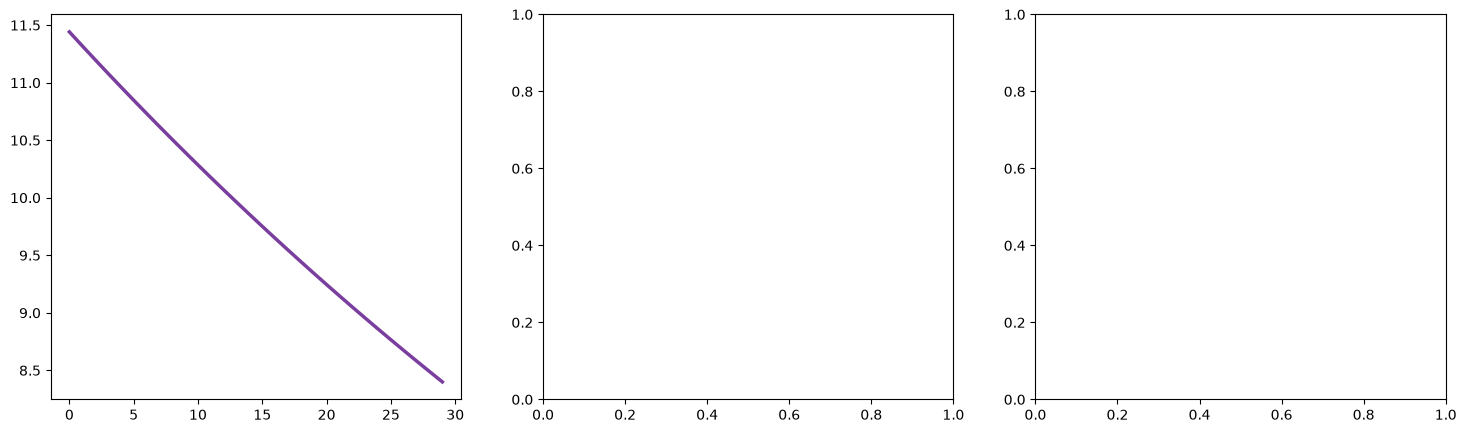

interactive(children=(FloatSlider(value=0.97, description='Paciencia (β)', max=0.999, min=0.9, step=0.01), Flo…

In [5]:
# ==============================================================================
# FUNCIÓN DE GRAFICACIÓN INTERACTIVA EN 3 PANELES
# ==============================================================================

def plot_consumption_saving(beta_val=0.97, R_val=0.02, profile="constant"):
    # Cargar parámetros configurados
    params_interactive = ConsumptionSavingParameters(T=30, beta=beta_val, R=R_val)
    W = generate_income_profile(profile, params_interactive.T)
    
    # Resolver usando el solver corregido
    res = solve_foc_fsolve(params_interactive, W)
    
    # Crear la figura de 3 paneles
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    t_axis = np.arange(params_interactive.T)
    
    # --- PANEL 1: CONSUMO E INGRESOS ---
    axs[0].plot(t_axis, res["C"], color='#7A3E9F', linewidth=2.5, label='Consumo Óptimo (C)')
    axs[0].plot(t_axis, res["W"], color='#8EAD3A', linewidth=2.5, linestyle='--', label='Ingreso Salarial (W)')
    axs[0].set_title('Consumo e Ingresos a lo largo del Ciclo de Vida', fontsize=11, fontweight='bold', pad=10)
    axs[0].set_xlabel('Periodo (t)', fontsize=9)
    axs[0].set_ylabel('Unidades de Bienes', fontsize=9)
    axs[0].grid(True, linestyle=':', alpha=0.6)
    axs[0].legend(loc='best', fontsize=8)
    
    # --- PANEL 2: ACTIVOS FINANCIEROS (AHORRO Y DEUDA) ---
    axs[1].plot(t_axis, res["B"], color='#004C97', linewidth=2.5, label='Activos Financieros (B)')
    axs[1].fill_between(t_axis, res["B"], 0, where=(res["B"] >= 0), color='#004C97', alpha=0.15, label='Posición Acreedora (Ahorro)')
    axs[1].fill_between(t_axis, res["B"], 0, where=(res["B"] < 0), color='#D95319', alpha=0.15, label='Posición Deudora (Deuda)')
    axs[1].axhline(0.0, color='black', linestyle=':', alpha=0.5)
    axs[1].set_title('Evolución de Activos Financieros', fontsize=11, fontweight='bold', pad=10)
    axs[1].set_xlabel('Periodo (t)', fontsize=9)
    axs[1].set_ylabel('Riqueza Neta', fontsize=9)
    axs[1].grid(True, linestyle=':', alpha=0.6)
    axs[1].legend(loc='best', fontsize=8)
    
    # --- PANEL 3: UTILIDAD DESCONTADA ---
    axs[2].plot(t_axis, res["U"], color='#D95319', linewidth=2.0, label=r'Utilidad ($\beta^t \ln C_t$)')
    axs[2].set_title('Utilidad Descontada por Periodo', fontsize=11, fontweight='bold', pad=10)
    axs[2].set_xlabel('Periodo (t)', fontsize=9)
    axs[2].set_ylabel('Utilidad', fontsize=9)
    axs[2].grid(True, linestyle=':', alpha=0.6)
    axs[2].legend(loc='best', fontsize=8)
    
    plt.tight_layout()
    plt.show()

# Configurar controles interactivos
interact(
    plot_consumption_saving,
    beta_val=FloatSlider(value=0.97, min=0.90, max=0.999, step=0.01, description='Paciencia (β)'),
    R_val=FloatSlider(value=0.02, min=-0.05, max=0.15, step=0.01, description='Interés (R)'),
    profile=Dropdown(options=["constant", "increasing", "retirement"], value="constant", description='Perfil Salarial')
);


## 5. Buenas Prácticas Aplicadas en este Laboratorio
1.  **Higiene del Sistema de Optimización**: El modelo evita declarar variables globales. Los resolvedores reciben un dataclass `ConsumptionSavingParameters` facilitando la escalabilidad del modelo.
2.  **Modularización Externa**: El "motor matemático" se aloja de forma independiente en `src/macroaicomp/models/consumption_savings.py`, permitiendo verificar la corrección del solver con pytest antes de renderizar la interfaz de usuario.
3.  **Control de Versiones Limpio**: Para cumplir con la directiva del proyecto, los metadatos y outputs interactivos de este cuaderno son removidos automáticamente por `nbstripout` antes de confirmar cualquier commit.


## 6. Cuaderno de Bitácora (Actividades para el Alumno)

Responde a las siguientes cuestiones analíticas en tu Cuaderno de Bitácora a partir del análisis interactivo:

1.  **El Experimento de Paciencia Intertemporal**:
    *   Selecciona el perfil salarial `constant`. Con la calibración base ($\beta=0.97, R=0.02$), la trayectoria del consumo óptimo decrece con el tiempo. Explica económicamente por qué ocurre esto relacionándolo con la tasa de descuento subjetiva ($\theta$) y la tasa de interés real ($R$).
    *   Desplaza el deslizador de la paciencia ($\beta$) hasta $0.99$. ¿Qué ocurre con la pendiente del consumo? Explica el concepto de "paciencia subjetiva" y por qué ahora el consumidor decide endeudarse al principio para consumir más en el futuro.
2.  **El Efecto de la Jubilación**:
    *   Selecciona el perfil salarial `retirement`. Observa que el salario cae a $0$ a partir del periodo 20.
    *   Describe la trayectoria de activos financieros (Panel 2). ¿Por qué el perfil tiene forma de pirámide y su pico máximo coincide exactamente con el periodo 19?
    *   ¿Cómo se modifica este comportamiento si la tasa de interés real ($R$) se incrementa sustancialmente a $10\%$? ¿Qué ocurre con el nivel de consumo en la jubilación?
3.  **Perfecta Movilidad en Mercados de Capitales**:
    *   En este modelo asumimos mercados de capitales perfectos (sin restricciones de liquidez). Si el banco impusiese una restricción que impidiera el endeudamiento ($B_t \ge 0$), ¿cómo afectaría esto a la trayectoria de consumo del perfil `increasing`? Justifica tu respuesta teóricamente.
